Title: LEE_Detection_REA.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data

Author: Onno Nennecke on 21.03.2025 Modified: 21.04.2026

Input data: 

- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/REA/\*.nc'

Output data:

- LEE Tables: LEE_dat_14_REA.csv, LEE_dat_7_REA.csv, LEE_dat_REA.csv, LEE_dat_14_selection_REA.csv, LEE_dat_7_selection_REA.csv, LEE_vl_REA.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob


### Read Model output data

In [2]:
path = '/climca/people/onennecke/model_output/REA/'


files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets.load()

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.000.000.000.000.000.000.000.000.00...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens001' 'ens002' ... 'ens125' 'ens126'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens001' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB 7.494 5.737 ... 5.688 4.226
    demand         (ESM_run, time) float64 155kB 1.426e+03 ... 1.468e+03
    sfcWind        (ESM_run, time) float64 155kB 3.754 3.078 ... 7.547 5.048
    rsds           (ESM_run, time) float32 78kB 92.87 97.36 ... 82.89 94.04
    tas            (ESM_run, time) float32 78kB 7.747 6.172 ... 5.239 3.865
    tasmax         (ESM_run, time) float32 78kB 11.15 10.78 ... 6.948 5.621
    wind_off_prod  (ESM_run, time) float64 155kB 9.914 6.89 ... 66.37 53.08
    wind_on_prod   (ESM_run, time) float64 155kB 48.57 34.91 ... 402.8 185.0
    solar_prod     (ESM_run, time) float64 155kB 152.2 162.7 ... 120.0 147.6
    total_prod     (ESM_run, time) float64 155kB 210.6 204.5 ... 589.1 385.7
    Netto          (ESM_run, time) float64 155kB -1.215e+03 ... -1.082e+03
    Residual_load  (ESM_run, time) float64 155kB 1.215e+03 ... 1.082e+03

#### Identification of low energy events

In [3]:
# RL = ts_datasets['Residual_load_adj']
RL = ts_datasets['Residual_load']

RL.values

array([[1215.38239987, 1244.02289537, 1207.35953333, ...,  940.56608177,
         940.50054212,  870.94701363],
       [1218.52564306, 1215.02051351, 1145.51645991, ..., 1139.40556149,
        1096.8565985 ,  360.32264952],
       [1218.52564306, 1215.02051351, 1145.51645991, ..., 1016.05556885,
        1023.91482723, 1141.59582337],
       ...,
       [1084.13626015,  984.92289462,  717.08158469, ...,  288.76951119,
         593.39833781, 1047.7777195 ],
       [1084.13626015,  984.92289462,  717.08158469, ..., 1101.34500783,
         705.88146371, 1081.67772904],
       [1084.13626015,  984.92289462,  717.08158469, ...,   19.20893715,
         860.00477519, 1081.84294479]])

In [4]:
# Calculate the rolling means
ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()
# ts_datasets

In [5]:
ts_datasets.load()

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.000.000.000.000.000.000.000.000.00...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens001' 'ens002' ... 'ens125' 'ens126'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens001' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables: (12/14)
    temp           (ESM_run, time) float64 155kB 7.494 5.737 ... 5.688 4.226
    demand         (ESM_run, time) float64 155kB 1.426e+03 ... 1.468e+03
    sfcWind        (ESM_run, time) float64 155kB 3.754 3.078 ... 7.547 5.048
    rsds           (ESM_run, time) float32 78kB 92.87 97.36 ... 82.89 94.04
    tas            (ESM_run, time) float32 78kB 7.747 6.172 ... 5.239 3.865
    tasmax         (ESM_run, time) float32 78kB 11.15 10.78 ... 6.948 5.621
    ...             ...
    solar_prod     (ESM_run, time) float64 155kB 152.2 162.7 ... 120.0 147.6
    total_prod     (ESM_run, time) float64 155kB 210.6 204.5 ... 589.1 385.7
    Netto          (ESM_run, time) float64 155kB -1.215e+03 ... -1.082e+03
    Residual_load  (ESM_run, time) float64 155kB 1.215e+03 ... 1.082e+03
    RL_mov_avg_7   (ESM_run, time) float64 155kB nan nan nan ... 706.2 747.4
    RL_mov_avg_14  (ESM_run, time) float64 155kB nan nan nan ... 613.6 617.3

In [7]:
print(ts_datasets.sel(ESM_run='CESM2_LE_REA_ens001').Residual_load.values[0:10])
print(ts_datasets.sel(ESM_run='CESM2_LE_REA_ens001').RL_mov_avg_7.values[0:10])

[1215.38239987 1244.02289537 1207.35953333 1216.20473731 1170.47749016
  789.94321219  492.94193135  737.01112671 1013.53554639 1236.8602478 ]
[          nan           nan           nan           nan           nan
           nan 1048.04745708  979.70870377  946.78193963  950.99632742]


In [8]:
(777.52873511 + 96.93869171 + 535.2921622 + 736.15298075 + 1242.50983711 + 1350.38753392 + 1179.10597113) / 7

845.4165588471429

##### Threshold (From other data)

In [11]:
thresh_perc = 0.95

In [9]:
# # Select all ESM_runs with period 'week'
# ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
# # RL_week = ts_datasets_week['Residual_load_adj']
# RL_week = ts_datasets_week['Residual_load']
# threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week = np.float64(1319.138650687668)


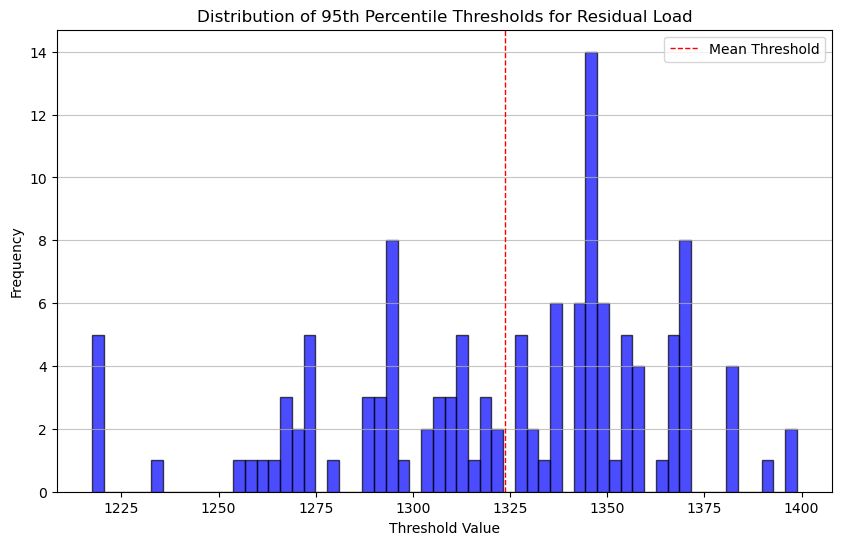

In [12]:
# Test
threshs = []
for esm_run in ts_datasets.ESM_run.values:
    ts_datasets_tst = ts_datasets.sel(ESM_run=esm_run)
    # RL_tst = ts_datasets_tst['Residual_load_adj']
    RL_tst = ts_datasets_tst['Residual_load']
    threshold_tst = np.quantile(RL_tst.values.flatten(), thresh_perc)
    threshs.append(threshold_tst)

# Plot the thresholds as a distribution
plt.figure(figsize=(10, 6))
plt.hist(threshs, bins=60, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of 95th Percentile Thresholds for Residual Load')
plt.xlabel('Threshold Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(np.mean(threshs), color='red', linestyle='dashed', linewidth=1, label='Mean Threshold')
plt.legend()
plt.show()

In [13]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool_1 = xr.where(RL > threshold_week, True, False)
exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold_week, True, False)
exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold_week, True, False)

In [14]:
# Look for events without any rolling mean


# Count number of true values overall
count_exceed_1 = exceed_bool_1.sum(dim='time').sum(dim='ESM_run')
count_exceed_1.values
# exceed_bool_1.time
# np.zeros_like(exceed_bool_1, dtype=int)

array(1316)

### Days above threshold (dat) 

- Take each day as its own event (not really events but just days above threshold)

In [15]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_1.values)
n_dat = run_idx.size

# 2) Create a flat counter 1…n_dat
labels = np.arange(1, n_dat + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat = np.zeros_like(exceed_bool_1.values, dtype=int)
dat[run_idx, time_idx] = labels

# wrap back into an xarray
dat = xr.DataArray(
    dat,
    coords=exceed_bool_1.coords,
    dims=exceed_bool_1.dims,
    name="dat"
)

n_dat = n_dat
dat

<xarray.DataArray 'dat' (ESM_run: 126, time: 154)> Size: 155kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    sim       (ESM_run) <U90 45kB 'c2.000.000.000.000.000.000.000.000.000.000...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U12 48B 'CESM2_LE_REA'
    run       (ESM_run) <U6 3kB 'ens001' 'ens002' 'ens003' ... 'ens125' 'ens126'
  * ESM_run   (ESM_run) <U19 10kB 'CESM2_LE_REA_ens001' ... 'CESM2_LE_REA_ens...
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [16]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_7.values)
n_dat_7 = run_idx.size

# 2) Create a flat counter 1…n_dat_7
labels = np.arange(1, n_dat_7 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_7 = np.zeros_like(exceed_bool_7.values, dtype=int)
dat_7[run_idx, time_idx] = labels

# wrap back into an xarray
dat_7 = xr.DataArray(
    dat_7,
    coords=exceed_bool_7.coords,
    dims=exceed_bool_7.dims,
    name="dat_7"
)

n_dat_7 = n_dat_7
dat_7

<xarray.DataArray 'dat_7' (ESM_run: 126, time: 154)> Size: 155kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    sim       (ESM_run) <U90 45kB 'c2.000.000.000.000.000.000.000.000.000.000...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U12 48B 'CESM2_LE_REA'
    run       (ESM_run) <U6 3kB 'ens001' 'ens002' 'ens003' ... 'ens125' 'ens126'
  * ESM_run   (ESM_run) <U19 10kB 'CESM2_LE_REA_ens001' ... 'CESM2_LE_REA_ens...
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [17]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_14.values)
n_dat_14 = run_idx.size

# 2) Create a flat counter 1…n_dat_14
labels = np.arange(1, n_dat_14 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_14 = np.zeros_like(exceed_bool_14.values, dtype=int)
dat_14[run_idx, time_idx] = labels

# wrap back into an xarray
dat_14 = xr.DataArray(
    dat_14,
    coords=exceed_bool_14.coords,
    dims=exceed_bool_14.dims,
    name="dat_14"
)

n_dat_14 = n_dat_14
dat_14

<xarray.DataArray 'dat_14' (ESM_run: 126, time: 154)> Size: 155kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    sim       (ESM_run) <U90 45kB 'c2.000.000.000.000.000.000.000.000.000.000...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U12 48B 'CESM2_LE_REA'
    run       (ESM_run) <U6 3kB 'ens001' 'ens002' 'ens003' ... 'ens125' 'ens126'
  * ESM_run   (ESM_run) <U19 10kB 'CESM2_LE_REA_ens001' ... 'CESM2_LE_REA_ens...
    country   float64 8B 9.0
    period    <U4 16B 'week'

### Events with rolling mean of 1 above threshold (events_vl) = events with varying length 

In [18]:
# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_vl[counter] = labeled_segment
    counter += 1

n_events_vl = current_label - 1
n_events_vl



686

In [25]:
def LEE_detection(events, n_events, t=RL['time'].values, dur = 7, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue
            print(f"Processing event {ev} for run {i+1}/{len(RL.ESM_run)}")

            end_idx = np.where(events[i] == ev)[0][0]
            start_idx = end_idx - dur + 1

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM.values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                # 'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)


In [26]:
LEE_dat = LEE_detection(dat, n_dat, dur = 1)

Processing event 1 for run 1/126
Processing event 2 for run 1/126
Processing event 3 for run 1/126
Processing event 4 for run 1/126
Processing event 5 for run 2/126
Processing event 6 for run 2/126
Processing event 7 for run 2/126
Processing event 8 for run 2/126
Processing event 9 for run 2/126
Processing event 10 for run 2/126
Processing event 11 for run 2/126
Processing event 12 for run 2/126
Processing event 13 for run 2/126
Processing event 14 for run 2/126
Processing event 15 for run 2/126
Processing event 16 for run 2/126
Processing event 17 for run 2/126
Processing event 18 for run 2/126
Processing event 19 for run 2/126
Processing event 20 for run 3/126
Processing event 21 for run 3/126
Processing event 22 for run 3/126
Processing event 23 for run 3/126
Processing event 24 for run 3/126
Processing event 25 for run 3/126
Processing event 26 for run 3/126
Processing event 27 for run 3/126
Processing event 28 for run 4/126
Processing event 29 for run 4/126
Processing event 30 for

In [28]:
LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_REA.csv', index=False)

LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-24,2025-12-24,2025-12-24,83,83,83,1,1375.133987,1375.133987,0.0,1375.133987,1,CESM2_LE_REA,CESM2_LE_REA_ens001,2025
1,2025-12-30,2025-12-30,2025-12-30,89,89,89,1,1371.039307,1371.039307,0.0,1371.039307,2,CESM2_LE_REA,CESM2_LE_REA_ens001,2025
2,2026-02-02,2026-02-02,2026-02-02,123,123,123,1,1338.880850,1338.880850,0.0,1338.880850,3,CESM2_LE_REA,CESM2_LE_REA_ens001,2026
3,2026-02-08,2026-02-08,2026-02-08,129,129,129,1,1333.278046,1333.278046,0.0,1333.278046,4,CESM2_LE_REA,CESM2_LE_REA_ens001,2026
4,2025-10-27,2025-10-27,2025-10-27,25,25,25,1,1351.686297,1351.686297,0.0,1351.686297,5,CESM2_LE_REA,CESM2_LE_REA_ens002,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,2026-01-09,2026-01-09,2026-01-09,99,99,99,1,1335.646226,1335.646226,0.0,1335.646226,1312,CESM2_LE_REA,CESM2_LE_REA_ens125,2026
1312,2026-01-10,2026-01-10,2026-01-10,100,100,100,1,1370.364462,1370.364462,0.0,1370.364462,1313,CESM2_LE_REA,CESM2_LE_REA_ens125,2026
1313,2025-10-16,2025-10-16,2025-10-16,14,14,14,1,1335.434145,1335.434145,0.0,1335.434145,1314,CESM2_LE_REA,CESM2_LE_REA_ens126,2025
1314,2026-01-09,2026-01-09,2026-01-09,99,99,99,1,1335.646226,1335.646226,0.0,1335.646226,1315,CESM2_LE_REA,CESM2_LE_REA_ens126,2026


In [29]:
LEE_dat_7 = LEE_detection(dat_7, n_dat_7, dur = 7)

Processing event 1 for run 4/126
Processing event 2 for run 4/126
Processing event 3 for run 4/126
Processing event 4 for run 4/126
Processing event 5 for run 4/126
Processing event 6 for run 4/126
Processing event 7 for run 4/126
Processing event 8 for run 4/126
Processing event 9 for run 4/126
Processing event 10 for run 5/126
Processing event 11 for run 5/126
Processing event 12 for run 5/126
Processing event 13 for run 5/126
Processing event 14 for run 5/126
Processing event 15 for run 5/126
Processing event 16 for run 5/126
Processing event 17 for run 18/126
Processing event 18 for run 19/126
Processing event 19 for run 22/126
Processing event 20 for run 22/126
Processing event 21 for run 22/126
Processing event 22 for run 22/126
Processing event 23 for run 22/126
Processing event 24 for run 22/126
Processing event 25 for run 22/126
Processing event 26 for run 22/126
Processing event 27 for run 23/126
Processing event 28 for run 23/126
Processing event 29 for run 23/126
Processing

In [30]:
LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-04,2025-12-10,2025-12-04 00:00:00.000000002,63,69,65,7,1425.222245,1373.934056,83.003962,9617.538389,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-05,2025-12-11,2025-12-05 00:00:00.000000006,64,70,70,7,1429.105401,1410.621576,13.040867,9874.351033,2,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-06,2025-12-12,2025-12-06 00:00:00.000000005,65,71,70,7,1429.105401,1404.533028,22.756518,9831.731197,3,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
3,2025-12-07,2025-12-13,2025-12-07 00:00:00.000000004,66,72,70,7,1429.105401,1390.595651,33.266426,9734.169558,4,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
4,2025-12-08,2025-12-14,2025-12-08 00:00:00.000000003,67,73,70,7,1429.105401,1392.593632,34.641379,9748.155423,5,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2025-11-23,2025-11-29,2025-11-23 00:00:00.000000004,52,58,56,7,1441.178700,1340.805876,115.689221,9385.641135,204,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
204,2025-11-24,2025-11-30,2025-11-24 00:00:00.000000003,53,59,56,7,1441.178700,1373.069668,51.677293,9611.487673,205,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
205,2025-11-25,2025-12-01,2025-11-25 00:00:00.000000002,54,60,56,7,1441.178700,1341.609041,85.778976,9391.263286,206,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
206,2025-12-02,2025-12-08,2025-12-02 00:00:00.000000006,61,67,67,7,1435.860168,1326.475117,70.886673,9285.325817,207,CESM2_LE_REA,CESM2_LE_REA_ens123,2025


In [31]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_7['ESM_run'].ne(LEE_dat_7['ESM_run'].shift())
not_consecutive = (LEE_dat_7['date_start'] - LEE_dat_7['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_7['event'] = is_new_event.cumsum()
LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-04,2025-12-10,2025-12-04 00:00:00.000000002,63,69,65,7,1425.222245,1373.934056,83.003962,9617.538389,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-05,2025-12-11,2025-12-05 00:00:00.000000006,64,70,70,7,1429.105401,1410.621576,13.040867,9874.351033,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-06,2025-12-12,2025-12-06 00:00:00.000000005,65,71,70,7,1429.105401,1404.533028,22.756518,9831.731197,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
3,2025-12-07,2025-12-13,2025-12-07 00:00:00.000000004,66,72,70,7,1429.105401,1390.595651,33.266426,9734.169558,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
4,2025-12-08,2025-12-14,2025-12-08 00:00:00.000000003,67,73,70,7,1429.105401,1392.593632,34.641379,9748.155423,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2025-11-23,2025-11-29,2025-11-23 00:00:00.000000004,52,58,56,7,1441.178700,1340.805876,115.689221,9385.641135,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
204,2025-11-24,2025-11-30,2025-11-24 00:00:00.000000003,53,59,56,7,1441.178700,1373.069668,51.677293,9611.487673,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
205,2025-11-25,2025-12-01,2025-11-25 00:00:00.000000002,54,60,56,7,1441.178700,1341.609041,85.778976,9391.263286,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
206,2025-12-02,2025-12-08,2025-12-02 00:00:00.000000006,61,67,67,7,1435.860168,1326.475117,70.886673,9285.325817,67,CESM2_LE_REA,CESM2_LE_REA_ens123,2025


In [32]:
LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_REA.csv', index=False)

LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-04,2025-12-10,2025-12-04 00:00:00.000000002,63,69,65,7,1425.222245,1373.934056,83.003962,9617.538389,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-05,2025-12-11,2025-12-05 00:00:00.000000006,64,70,70,7,1429.105401,1410.621576,13.040867,9874.351033,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-06,2025-12-12,2025-12-06 00:00:00.000000005,65,71,70,7,1429.105401,1404.533028,22.756518,9831.731197,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
3,2025-12-07,2025-12-13,2025-12-07 00:00:00.000000004,66,72,70,7,1429.105401,1390.595651,33.266426,9734.169558,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
4,2025-12-08,2025-12-14,2025-12-08 00:00:00.000000003,67,73,70,7,1429.105401,1392.593632,34.641379,9748.155423,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2025-11-23,2025-11-29,2025-11-23 00:00:00.000000004,52,58,56,7,1441.178700,1340.805876,115.689221,9385.641135,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
204,2025-11-24,2025-11-30,2025-11-24 00:00:00.000000003,53,59,56,7,1441.178700,1373.069668,51.677293,9611.487673,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
205,2025-11-25,2025-12-01,2025-11-25 00:00:00.000000002,54,60,56,7,1441.178700,1341.609041,85.778976,9391.263286,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025
206,2025-12-02,2025-12-08,2025-12-02 00:00:00.000000006,61,67,67,7,1435.860168,1326.475117,70.886673,9285.325817,67,CESM2_LE_REA,CESM2_LE_REA_ens123,2025


In [33]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_7.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_7_max_cum_RL = LEE_dat_7.loc[idx].reset_index(drop=True)
LEE_dat_7_max_cum_RL


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-05,2025-12-11,2025-12-05 00:00:00.000000006,64,70,70,7,1429.105401,1410.621576,13.040867,9874.351033,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-21,2025-12-27,2025-12-21 00:00:00.000000006,80,86,86,7,1394.276141,1328.120522,66.061356,9296.843654,2,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-05,2025-12-11,2025-12-05 00:00:00.000000006,64,70,70,7,1427.741949,1410.426797,12.770721,9872.987580,3,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
3,2025-12-04,2025-12-10,2025-12-04 00:00:00.000000005,63,69,68,7,1431.414752,1334.704016,110.618959,9342.928115,4,CESM2_LE_REA,CESM2_LE_REA_ens018,2025
4,2025-12-04,2025-12-10,2025-12-04 00:00:00.000000005,63,69,68,7,1431.414752,1334.704016,110.618959,9342.928115,5,CESM2_LE_REA,CESM2_LE_REA_ens019,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2025-11-09,2025-11-15,2025-11-09 00:00:00.000000000,38,44,38,7,1422.196539,1382.722193,24.879580,9679.055350,63,CESM2_LE_REA,CESM2_LE_REA_ens110,2025
63,2025-11-09,2025-11-15,2025-11-09 00:00:00.000000000,38,44,38,7,1422.196539,1382.722193,24.879580,9679.055350,64,CESM2_LE_REA,CESM2_LE_REA_ens111,2025
64,2025-11-24,2025-11-30,2025-11-24 00:00:00.000000003,53,59,56,7,1441.178700,1373.069668,51.677293,9611.487673,65,CESM2_LE_REA,CESM2_LE_REA_ens115,2025
65,2025-11-24,2025-11-30,2025-11-24 00:00:00.000000003,53,59,56,7,1441.178700,1373.069668,51.677293,9611.487673,66,CESM2_LE_REA,CESM2_LE_REA_ens116,2025


In [34]:
LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_REA.csv', index=False)


In [35]:
LEE_dat_14 = LEE_detection(dat_14, n_dat_14, dur = 14)

Processing event 1 for run 4/126
Processing event 2 for run 4/126
Processing event 3 for run 4/126
Processing event 4 for run 5/126
Processing event 5 for run 5/126
Processing event 6 for run 5/126
Processing event 7 for run 22/126
Processing event 8 for run 22/126
Processing event 9 for run 22/126
Processing event 10 for run 22/126
Processing event 11 for run 23/126
Processing event 12 for run 23/126
Processing event 13 for run 23/126
Processing event 14 for run 23/126
Processing event 15 for run 23/126
Processing event 16 for run 23/126
Processing event 17 for run 23/126
Processing event 18 for run 23/126
Processing event 19 for run 24/126
Processing event 20 for run 24/126
Processing event 21 for run 24/126
Processing event 22 for run 24/126
Processing event 23 for run 24/126
Processing event 24 for run 25/126
Processing event 25 for run 25/126
Processing event 26 for run 25/126
Processing event 27 for run 25/126
Processing event 28 for run 25/126
Processing event 29 for run 26/126


In [36]:
LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-02,2025-12-15,2025-12-02 00:00:00.000000009,61,74,70,14,1429.105401,1334.336350,138.943056,18680.708907,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1429.105401,1335.596453,137.897863,18698.350345,2,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-04,2025-12-17,2025-12-04 00:00:00.000000007,63,76,70,14,1429.105401,1330.462067,153.822689,18626.468942,3,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
3,2025-12-02,2025-12-15,2025-12-02 00:00:00.000000009,61,74,70,14,1427.741949,1333.421289,138.754469,18667.898043,4,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
4,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1427.741949,1335.701022,136.980683,18699.814310,5,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
5,2025-12-04,2025-12-17,2025-12-04 00:00:00.000000007,63,76,70,14,1427.741949,1335.366439,138.005910,18695.130153,6,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
6,2025-11-26,2025-12-09,2025-11-26 00:00:00.000000013,55,68,68,14,1448.938430,1323.492566,141.178834,18528.895930,7,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
7,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000013,56,69,69,14,1457.177881,1349.137571,130.089164,18887.925987,8,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
8,2025-11-28,2025-12-11,2025-11-28 00:00:00.000000012,57,70,69,14,1457.177881,1333.507427,137.843400,18669.103979,9,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
9,2025-11-29,2025-12-12,2025-11-29 00:00:00.000000011,58,71,69,14,1457.177881,1332.237884,137.493740,18651.330383,10,CESM2_LE_REA,CESM2_LE_REA_ens022,2025


In [37]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_14['ESM_run'].ne(LEE_dat_14['ESM_run'].shift())
not_consecutive = (LEE_dat_14['date_start'] - LEE_dat_14['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_14['event'] = is_new_event.cumsum()
# LEE_dat_14

In [38]:
LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_REA.csv', index=False)

LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-02,2025-12-15,2025-12-02 00:00:00.000000009,61,74,70,14,1429.105401,1334.336350,138.943056,18680.708907,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1429.105401,1335.596453,137.897863,18698.350345,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
2,2025-12-04,2025-12-17,2025-12-04 00:00:00.000000007,63,76,70,14,1429.105401,1330.462067,153.822689,18626.468942,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
3,2025-12-02,2025-12-15,2025-12-02 00:00:00.000000009,61,74,70,14,1427.741949,1333.421289,138.754469,18667.898043,2,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
4,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1427.741949,1335.701022,136.980683,18699.814310,2,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
5,2025-12-04,2025-12-17,2025-12-04 00:00:00.000000007,63,76,70,14,1427.741949,1335.366439,138.005910,18695.130153,2,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
6,2025-11-26,2025-12-09,2025-11-26 00:00:00.000000013,55,68,68,14,1448.938430,1323.492566,141.178834,18528.895930,3,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
7,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000013,56,69,69,14,1457.177881,1349.137571,130.089164,18887.925987,3,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
8,2025-11-28,2025-12-11,2025-11-28 00:00:00.000000012,57,70,69,14,1457.177881,1333.507427,137.843400,18669.103979,3,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
9,2025-11-29,2025-12-12,2025-11-29 00:00:00.000000011,58,71,69,14,1457.177881,1332.237884,137.493740,18651.330383,3,CESM2_LE_REA,CESM2_LE_REA_ens022,2025


In [39]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_14.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_14_max_cum_RL = LEE_dat_14.loc[idx].reset_index(drop=True)
LEE_dat_14_max_cum_RL

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1429.105401,1335.596453,137.897863,18698.350345,1,CESM2_LE_REA,CESM2_LE_REA_ens004,2025
1,2025-12-03,2025-12-16,2025-12-03 00:00:00.000000008,62,75,70,14,1427.741949,1335.701022,136.980683,18699.814310,2,CESM2_LE_REA,CESM2_LE_REA_ens005,2025
2,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000013,56,69,69,14,1457.177881,1349.137571,130.089164,18887.925987,3,CESM2_LE_REA,CESM2_LE_REA_ens022,2025
3,2025-11-29,2025-12-12,2025-11-29 00:00:00.000000002,58,71,60,14,1447.187211,1357.089898,62.208684,18999.258566,4,CESM2_LE_REA,CESM2_LE_REA_ens023,2025
4,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000004,56,69,60,14,1447.187211,1350.322864,57.231650,18904.520102,5,CESM2_LE_REA,CESM2_LE_REA_ens024,2025
5,2025-12-05,2025-12-18,2025-12-05 00:00:00.000000013,64,77,77,14,1475.607627,1328.685671,105.187286,18601.599389,6,CESM2_LE_REA,CESM2_LE_REA_ens024,2025
6,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000004,56,69,60,14,1447.187211,1350.322864,57.231650,18904.520102,7,CESM2_LE_REA,CESM2_LE_REA_ens025,2025
7,2025-12-05,2025-12-18,2025-12-05 00:00:00.000000013,64,77,77,14,1475.607627,1328.685671,105.187286,18601.599389,8,CESM2_LE_REA,CESM2_LE_REA_ens025,2025
8,2025-11-27,2025-12-10,2025-11-27 00:00:00.000000004,56,69,60,14,1448.523087,1319.844078,85.585800,18477.817095,9,CESM2_LE_REA,CESM2_LE_REA_ens026,2025


In [40]:
LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_REA.csv', index=False)


### Event detection for variable length

In [41]:
def LEE_detection_vl(events, n_events, t=RL['time'].values, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue

            start_idx = np.where(events[i] == ev)[0][0]
            end_idx = np.where(events[i] == ev)[0][-1]

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM.values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                # 'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)

In [42]:
LEE_vl = LEE_detection_vl(events_vl, n_events_vl)

In [43]:
LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_REA.csv', index=False)


In [44]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year
0,2025-12-24,2025-12-24,2025-12-24 00:00:00.000000000,83,83,83,1,1375.133987,1375.133987,0.000000,1375.133987,1,CESM2_LE_REA,CESM2_LE_REA_ens001,2025
1,2025-12-30,2025-12-30,2025-12-30 00:00:00.000000000,89,89,89,1,1371.039307,1371.039307,0.000000,1371.039307,2,CESM2_LE_REA,CESM2_LE_REA_ens001,2025
2,2026-02-02,2026-02-02,2026-02-02 00:00:00.000000000,123,123,123,1,1338.880850,1338.880850,0.000000,1338.880850,3,CESM2_LE_REA,CESM2_LE_REA_ens001,2026
3,2026-02-08,2026-02-08,2026-02-08 00:00:00.000000000,129,129,129,1,1333.278046,1333.278046,0.000000,1333.278046,4,CESM2_LE_REA,CESM2_LE_REA_ens001,2026
4,2025-10-27,2025-10-27,2025-10-27 00:00:00.000000000,25,25,25,1,1351.686297,1351.686297,0.000000,1351.686297,5,CESM2_LE_REA,CESM2_LE_REA_ens002,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,2026-01-09,2026-01-10,2026-01-09 00:00:00.000000001,99,100,100,2,1370.364462,1353.005344,17.359118,2706.010688,682,CESM2_LE_REA,CESM2_LE_REA_ens124,2026
682,2025-10-16,2025-10-16,2025-10-16 00:00:00.000000000,14,14,14,1,1335.434145,1335.434145,0.000000,1335.434145,683,CESM2_LE_REA,CESM2_LE_REA_ens125,2025
683,2026-01-09,2026-01-10,2026-01-09 00:00:00.000000001,99,100,100,2,1370.364462,1353.005344,17.359118,2706.010688,684,CESM2_LE_REA,CESM2_LE_REA_ens125,2026
684,2025-10-16,2025-10-16,2025-10-16 00:00:00.000000000,14,14,14,1,1335.434145,1335.434145,0.000000,1335.434145,685,CESM2_LE_REA,CESM2_LE_REA_ens126,2025
